# Heart Disease Prediction — Gradient Boosting Classifier

Boosting ensemble that fits new trees to the residual errors of the previous trees, minimizing a loss function via gradient descent.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## 2. Load Data

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Train-Test Split

In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Train Gradient Boosting Model

In [4]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

## 5. Evaluation

In [5]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Accuracy:  0.8197
Precision: 0.7895
Recall:    0.9091
F1-Score:  0.8451

              precision    recall  f1-score   support

  No Disease       0.87      0.71      0.78        28
     Disease       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



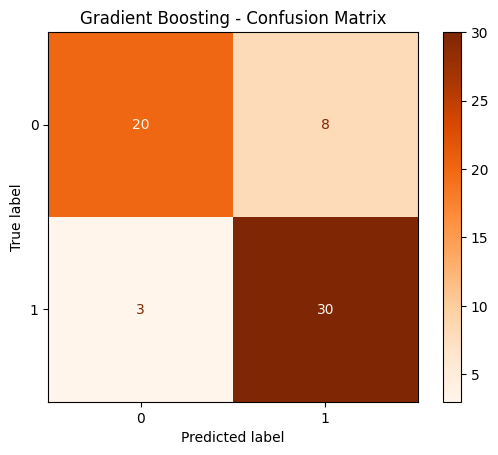

In [6]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Oranges')
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()

## 6. Learning Curve — Training Deviance

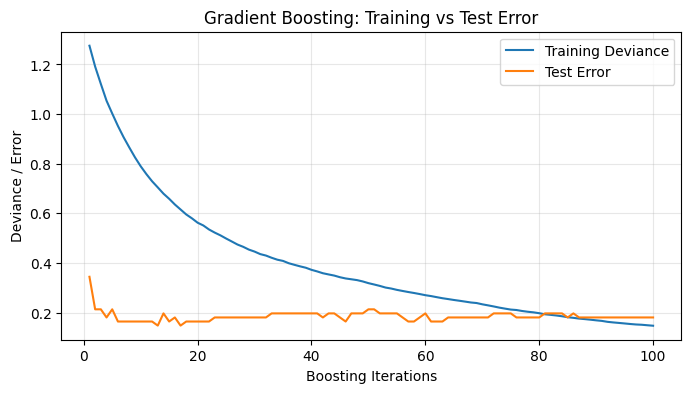

In [7]:
test_score = np.zeros(gb.n_estimators_, dtype=np.float64)
for i, y_pred_stage in enumerate(gb.staged_predict(X_test)):
    test_score[i] = 1 - accuracy_score(y_test, y_pred_stage)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(gb.n_estimators_) + 1, gb.train_score_, label='Training Deviance')
plt.plot(np.arange(gb.n_estimators_) + 1, test_score, label='Test Error')
plt.xlabel('Boosting Iterations')
plt.ylabel('Deviance / Error')
plt.title('Gradient Boosting: Training vs Test Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Hyperparameter Tuning (Grid Search)

In [8]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV Accuracy:', grid_search.best_score_)

best_gb = grid_search.best_estimator_
test_acc = accuracy_score(y_test, best_gb.predict(X_test))
print('Test Accuracy with Best Params:', test_acc)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}
Best CV Accuracy: 0.8182823129251702
Test Accuracy with Best Params: 0.819672131147541


## 8. Feature Importance

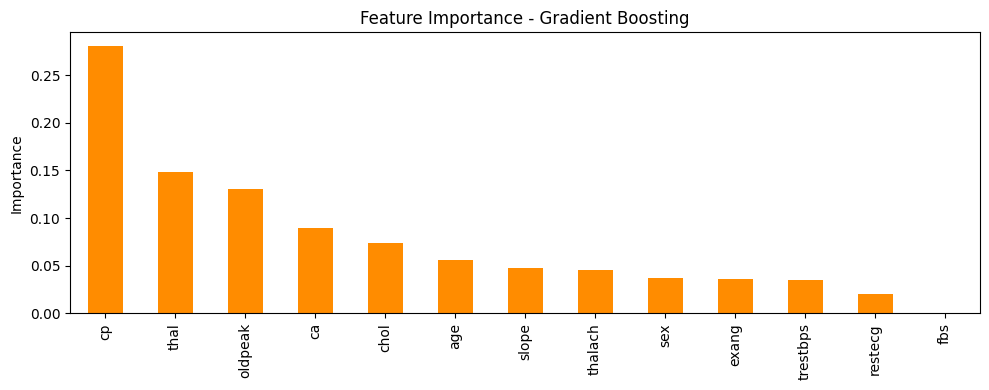

In [9]:
importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(10, 4), title='Feature Importance - Gradient Boosting', color='darkorange')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()